# Telco Customer Churn - Exploratory Data Analysis
This notebook analyses a Telco customer churn dataset to understand why customers leave and what keeps them engaged.

**Name:** Tshegofatso Chikwane

## Import Libraries

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## 1. Load and Inspect the Data
We load the CSV file and check its shape, columns and first few rows.

In [62]:
# LOAD AND INSPECT THE DATA

In [63]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

print(f"\nColumn names:\n{df.columns.tolist()}")

Dataset shape: 7043 rows, 21 columns

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [64]:
print("Data types:")
df.dtypes

Data types:


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [65]:
df.head(5)  # shows the top 5 rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [66]:
df.tail(5)  # shows the bottom 5 rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [67]:
df.info()   # shows variables and their data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 2. Check for Missing Values
Missing values are empty cells. We need to find them before cleaning.

In [68]:
missing = df.isnull().sum()  # checking for missing values

print("Missing Values per column:")
missing[missing > 0]

Missing Values per column:


Series([], dtype: int64)

## 3. Check for Duplicates
Duplicate rows are exact copies of each other. They skew our results so we remove them.

In [69]:
# checking for duplicates
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [70]:
# basic stats
basic_stats = df.describe()

print("Basic Stats:")
basic_stats

Basic Stats:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 4. Data Cleaning
We fix data types, handle missing values, and create useful new columns for analysis.

In [71]:
# remove duplicates
df = df.drop_duplicates()

In [72]:
# TotalCharges is stored as string - convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [73]:
# fill missing TotalCharges with 0 (new customers with no charges yet)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [74]:
# convert SeniorCitizen from 0/1 to Yes/No for readability
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

In [75]:
# convert Churn column to binary for calculations
df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [76]:
# create tenure groups for cohort analysis
df['Tenure Group'] = pd.cut(df['tenure'],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=['0-12 months', '13-24 months', '25-36 months',
            '37-48 months', '49-60 months', '61-72 months'])

In [77]:
# check rows remaining after data cleaning
print("\nAFTER DATA CLEANING")
print("Rows remaining:", len(df))
print("New columns added: Churn_Binary, Tenure Group")


AFTER DATA CLEANING
Rows remaining: 7043
New columns added: Churn_Binary, Tenure Group


In [78]:
# key metrics
print("\n--- KEY METRICS ---")
total = len(df)
churned = df['Churn_Binary'].sum()
print(f"Total Customers:   {total:,}")
print(f"Churned Customers: {churned:,}")
print(f"Retained Customers:{total - churned:,}")
print(f"Churn Rate:        {(churned/total*100):.2f}%")
print(f"Avg Monthly Charges: ${df['MonthlyCharges'].mean():.2f}")
print(f"Avg Tenure:        {df['tenure'].mean():.1f} months")


--- KEY METRICS ---
Total Customers:   7,043
Churned Customers: 1,869
Retained Customers:5,174
Churn Rate:        26.54%
Avg Monthly Charges: $64.76
Avg Tenure:        32.4 months


In [79]:
# churn by contract type
print("\n--- CHURN BY CONTRACT TYPE ---")
print(df.groupby('Contract')['Churn_Binary'].mean().mul(100).round(2).astype(str) + '%')


--- CHURN BY CONTRACT TYPE ---
Contract
Month-to-month    42.71%
One year          11.27%
Two year           2.83%
Name: Churn_Binary, dtype: object


In [80]:
# churn by internet service
print("\n--- CHURN BY INTERNET SERVICE ---")
print(df.groupby('InternetService')['Churn_Binary'].mean().mul(100).round(2).astype(str) + '%')


--- CHURN BY INTERNET SERVICE ---
InternetService
DSL            18.96%
Fiber optic    41.89%
No               7.4%
Name: Churn_Binary, dtype: object


In [81]:
# churn by tenure group
print("\n--- CHURN BY TENURE GROUP ---")
print(df.groupby('Tenure Group')['Churn_Binary'].mean().mul(100).round(2).astype(str) + '%')


--- CHURN BY TENURE GROUP ---
Tenure Group
0-12 months     47.68%
13-24 months    28.71%
25-36 months    21.63%
37-48 months    19.03%
49-60 months    14.42%
61-72 months     6.61%
Name: Churn_Binary, dtype: object


## 5. Visualizations
Now that the data is clean, we explore it using different types of charts.

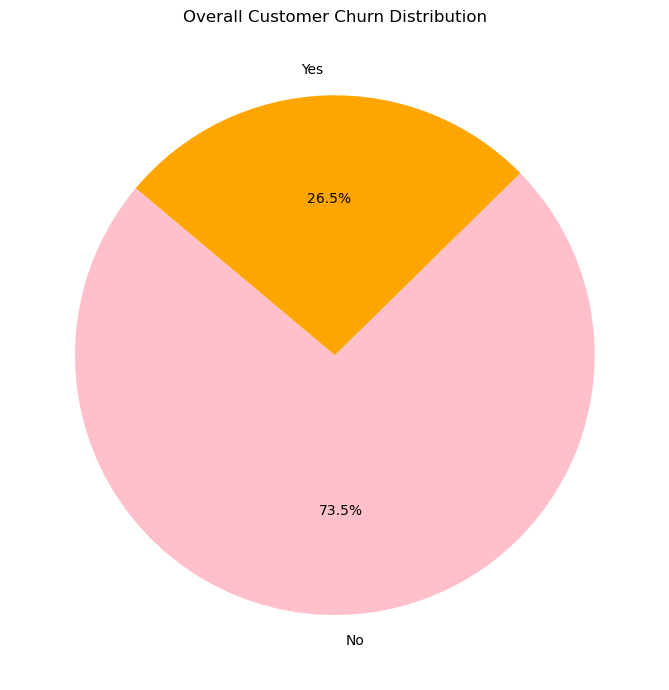

In [82]:
# Chart 1: Overall Churn Distribution - PIE CHART
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(churn_counts.values, labels=churn_counts.index,
        autopct='%1.1f%%',
        colors=['pink', 'orange'],
        startangle=140)
plt.title('Overall Customer Churn Distribution')
plt.tight_layout()
plt.show()

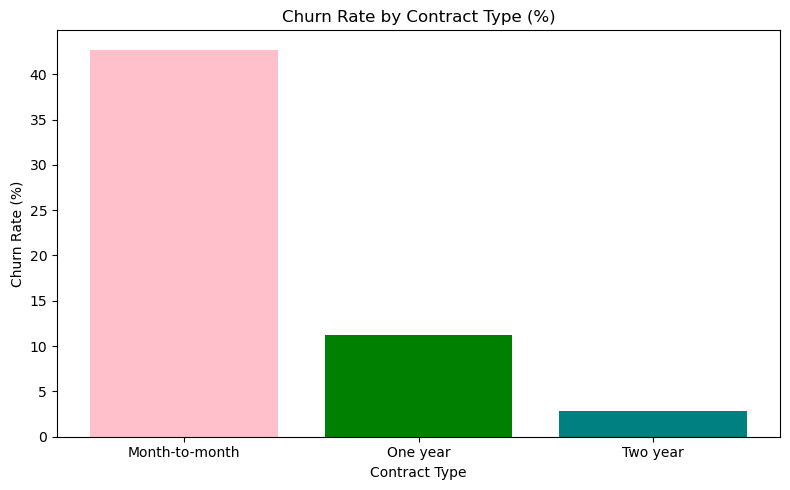

In [83]:
# Chart 2: Churn by Contract Type - BAR CHART
contract_churn = df.groupby('Contract')['Churn_Binary'].mean().mul(100).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(contract_churn.index, contract_churn.values, color=['pink', 'green', 'teal'])
plt.title('Churn Rate by Contract Type (%)')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

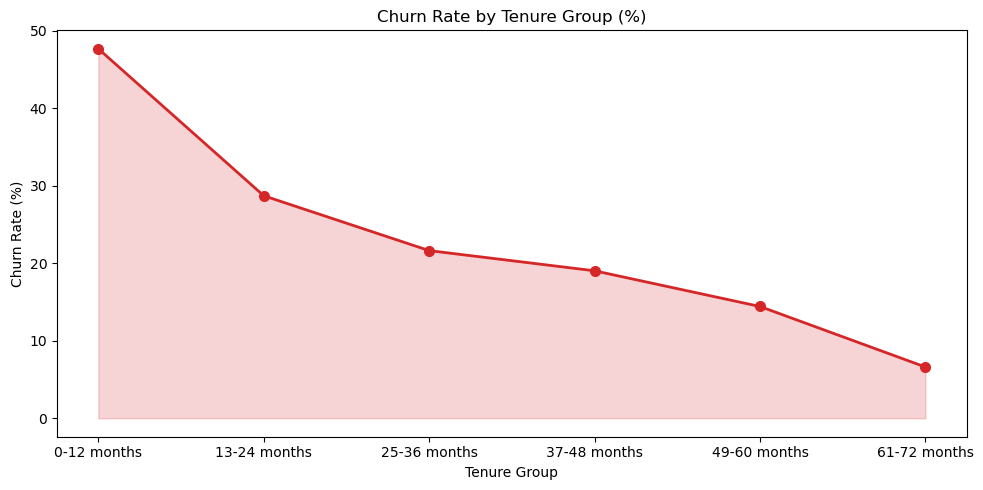

In [84]:
# Chart 3: Churn by Tenure Group - LINE CHART
tenure_churn = df.groupby('Tenure Group')['Churn_Binary'].mean().mul(100)

plt.figure(figsize=(10, 5))
plt.plot(tenure_churn.index.astype(str), tenure_churn.values, color='#d62728', marker='o', linewidth=2, markersize=7)
plt.fill_between(range(len(tenure_churn)), tenure_churn.values, alpha=0.2, color='#d62728')
plt.title('Churn Rate by Tenure Group (%)')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

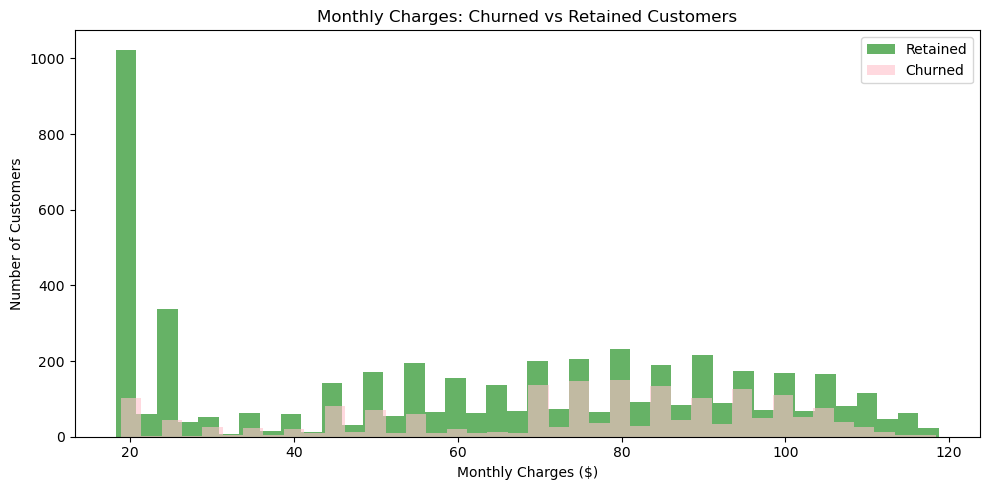

In [85]:
# Chart 4: Monthly Charges - Churned vs Retained - HISTOGRAM
plt.figure(figsize=(10, 5))
plt.hist(df[df['Churn'] == 'No']['MonthlyCharges'], bins=40, alpha=0.6, color='green', label='Retained')
plt.hist(df[df['Churn'] == 'Yes']['MonthlyCharges'], bins=40, alpha=0.6, color='pink', label='Churned')
plt.title('Monthly Charges: Churned vs Retained Customers')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()

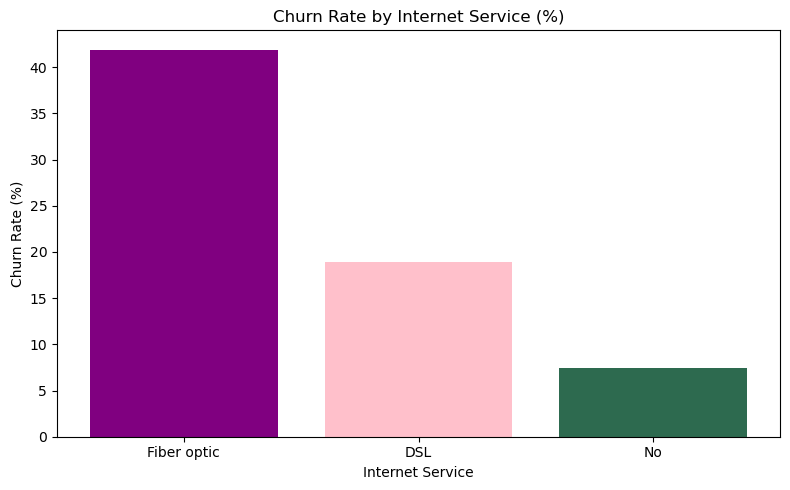

In [86]:
# Chart 5: Churn by Internet Service - BAR CHART
internet_churn = df.groupby('InternetService')['Churn_Binary'].mean().mul(100).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(internet_churn.index, internet_churn.values, color=['purple', 'pink', '#2d6a4f'])
plt.title('Churn Rate by Internet Service (%)')
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

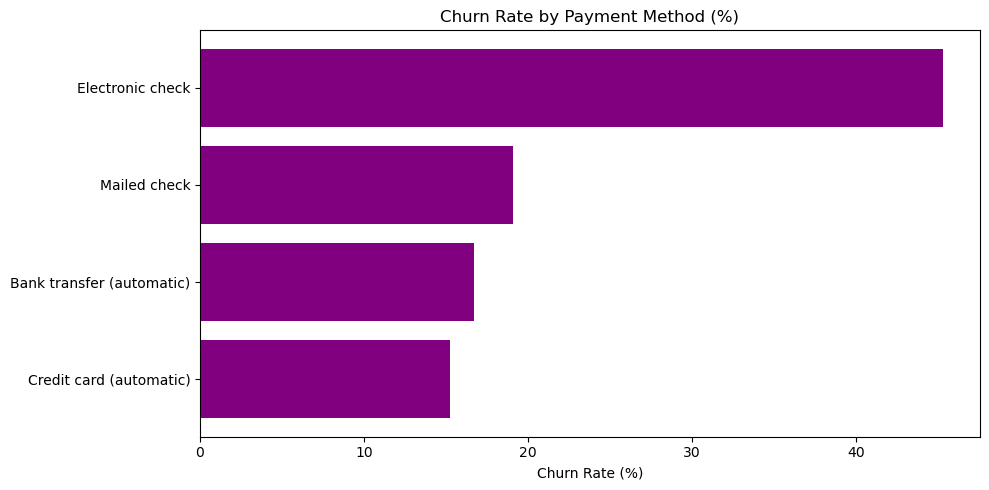

In [87]:
# Chart 6: Churn by Payment Method - HORIZONTAL BAR CHART
payment_churn = df.groupby('PaymentMethod')['Churn_Binary'].mean().mul(100).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(payment_churn.index[::-1], payment_churn.values[::-1], color='purple')
plt.title('Churn Rate by Payment Method (%)')
plt.xlabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

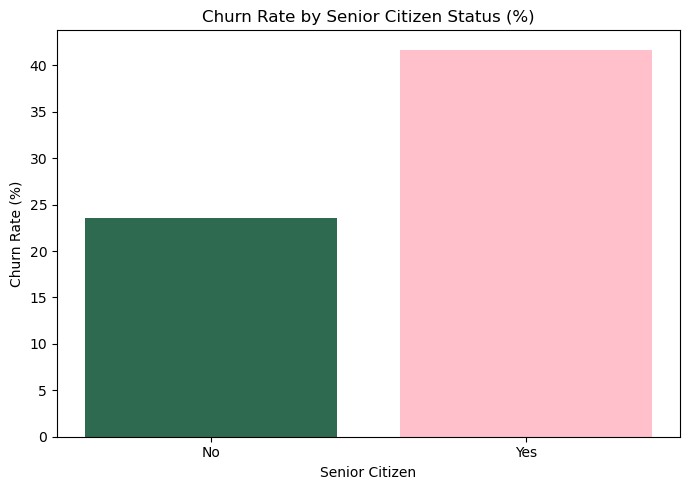

In [88]:
# Chart 7: Churn by Senior Citizen Status - BAR CHART
senior_churn = df.groupby('SeniorCitizen')['Churn_Binary'].mean().mul(100)

plt.figure(figsize=(7, 5))
plt.bar(senior_churn.index, senior_churn.values, color=['#2d6a4f', 'pink'])
plt.title('Churn Rate by Senior Citizen Status (%)')
plt.xlabel('Senior Citizen')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

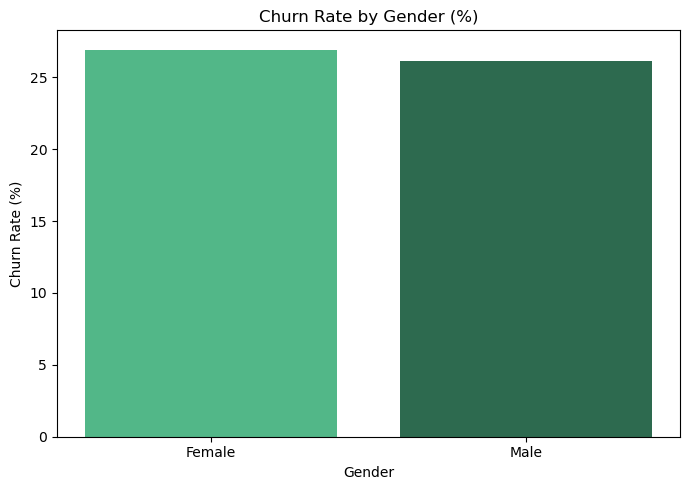

In [89]:
# Chart 8: Churn by Gender - BAR CHART
gender_churn = df.groupby('gender')['Churn_Binary'].mean().mul(100)

plt.figure(figsize=(7, 5))
plt.bar(gender_churn.index, gender_churn.values, color=['#52b788', '#2d6a4f'])
plt.title('Churn Rate by Gender (%)')
plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

## 6. Save the Clean Data
We save the cleaned dataset as a new CSV file for future use.

In [90]:
# save clean data
df.to_csv('telco_churn_clean.csv', index=False)
print("Clean data saved as telco_churn_clean.csv")

Clean data saved as telco_churn_clean.csv
